# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The AI Social Media Impact Dataset](https://www.kaggle.com/datasets/debayank2024/ai-and-social-media-impact-student-health-and-grades)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/debayank2024/ai-and-social-media-impact-student-health-and-grades/AI_SocialMedia_Student_Health_Dataset_clean.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('AI_SocialMedia_Student_Health_Dataset_clean.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Burnout_Level,Academic_Performance_Score,Academic_Failure_Risk
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90,4.05,Low,88.80,0
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94,4.65,Moderate,50.60,0
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75,5.28,Low,96.67,0
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38,3.66,Low,85.65,0
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04,3.25,Moderate,71.84,0


## last Five row

In [4]:
df.tail()

,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Burnout_Level,Academic_Performance_Score,Academic_Failure_Risk
14995,STU_14996,18,Non-binary,College,6.10,0.72,5.63,0.89,74.08,71.92,3.78,Moderate,77.43,0
14996,STU_14997,22,Female,University,4.55,1.20,7.20,0.00,73.72,85.84,5.06,Low,75.81,0
14997,STU_14998,13,Male,High School,7.83,1.46,6.22,0.64,70.03,86.62,4.76,Moderate,89.84,0
14998,STU_14999,20,Female,College,6.99,3.00,4.24,1.97,57.38,85.34,2.82,Severe,65.44,1
14999,STU_15000,14,Male,High School,3.73,3.03,6.39,1.50,71.69,78.62,4.37,Moderate,92.91,0


## Shape of our dataset

In [5]:
df.shape

(15000, 14)

## List out all columns

In [6]:
df.columns

Index(['Student_ID', 'Age', 'Gender', 'Education_Level',
       'Daily_Social_Media_Hours', 'Daily_AI_Tool_Usage_Hours', 'Sleep_Hours',
       'Physical_Activity_Hours', 'Mental_Health_Score',
       'Physical_Health_Score', 'Social_Isolation_Score', 'Burnout_Level',
       'Academic_Performance_Score', 'Academic_Failure_Risk'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Student_ID                     object
Age                             int64
Gender                         object
Education_Level                object
Daily_Social_Media_Hours      float64
Daily_AI_Tool_Usage_Hours     float64
Sleep_Hours                   float64
Physical_Activity_Hours       float64
Mental_Health_Score           float64
Physical_Health_Score         float64
Social_Isolation_Score        float64
Burnout_Level                  object
Academic_Performance_Score    float64
Academic_Failure_Risk           int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  15000 non-null  object 
 1   Age                         15000 non-null  int64  
 2   Gender                      15000 non-null  object 
 3   Education_Level             15000 non-null  object 
 4   Daily_Social_Media_Hours    15000 non-null  float64
 5   Daily_AI_Tool_Usage_Hours   15000 non-null  float64
 6   Sleep_Hours                 15000 non-null  float64
 7   Physical_Activity_Hours     15000 non-null  float64
 8   Mental_Health_Score         15000 non-null  float64
 9   Physical_Health_Score       15000 non-null  float64
 10  Social_Isolation_Score      15000 non-null  float64
 11  Burnout_Level               15000 non-null  object 
 12  Academic_Performance_Score  15000 non-null  float64
 13  Academic_Failure_Risk       150

## Check Null Value

In [9]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
Education_Level               0
Daily_Social_Media_Hours      0
Daily_AI_Tool_Usage_Hours     0
Sleep_Hours                   0
Physical_Activity_Hours       0
Mental_Health_Score           0
Physical_Health_Score         0
Social_Isolation_Score        0
Burnout_Level                 0
Academic_Performance_Score    0
Academic_Failure_Risk         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score,Social_Isolation_Score,Academic_Performance_Score,Academic_Failure_Risk
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,19.040667,4.537500,2.584580,6.544205,1.246332,72.513156,88.019761,4.312027,78.314859,0.060000
std,3.767257,2.398494,1.677988,1.269770,1.038349,9.245482,9.684253,1.162432,11.544651,0.237495
min,13.000000,0.000000,0.000000,2.000000,0.000000,32.560000,48.030000,0.970000,23.990000,0.000000
25%,16.000000,2.830000,1.310000,5.680000,0.310000,66.780000,81.520000,3.470000,70.530000,0.000000
50%,19.000000,4.500000,2.510000,6.550000,1.130000,73.760000,89.470000,4.280000,78.590000,0.000000
75%,22.000000,6.180000,3.740000,7.410000,1.950000,79.580000,97.160000,5.120000,86.700000,0.000000
max,25.000000,14.000000,9.500000,11.150000,5.000000,91.760000,99.980000,8.410000,99.980000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

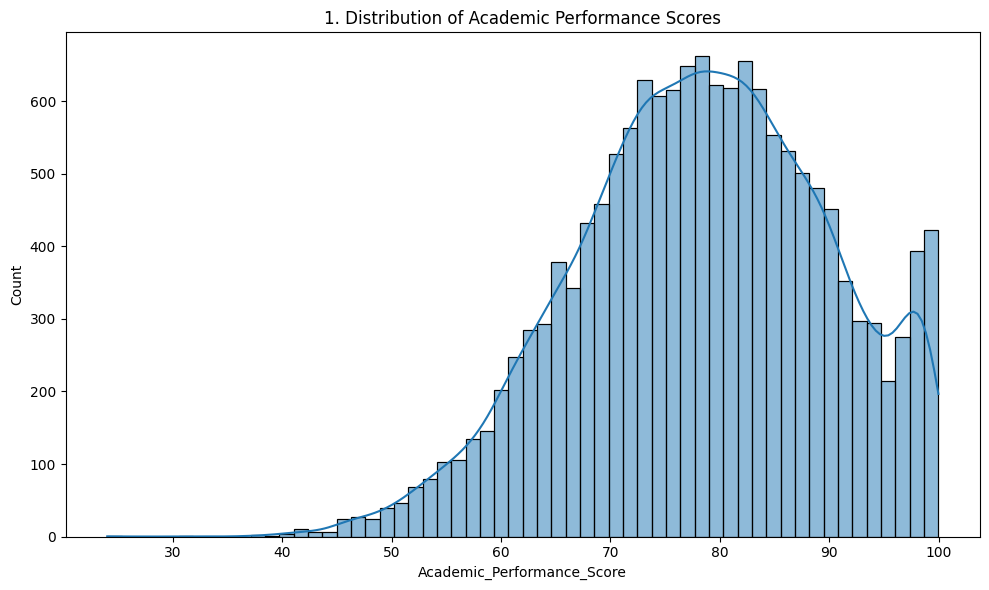

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Academic_Performance_Score', kde=True)
plt.title(f'{plot_no}. Distribution of Academic Performance Scores')
show_fig()
plot_no += 1

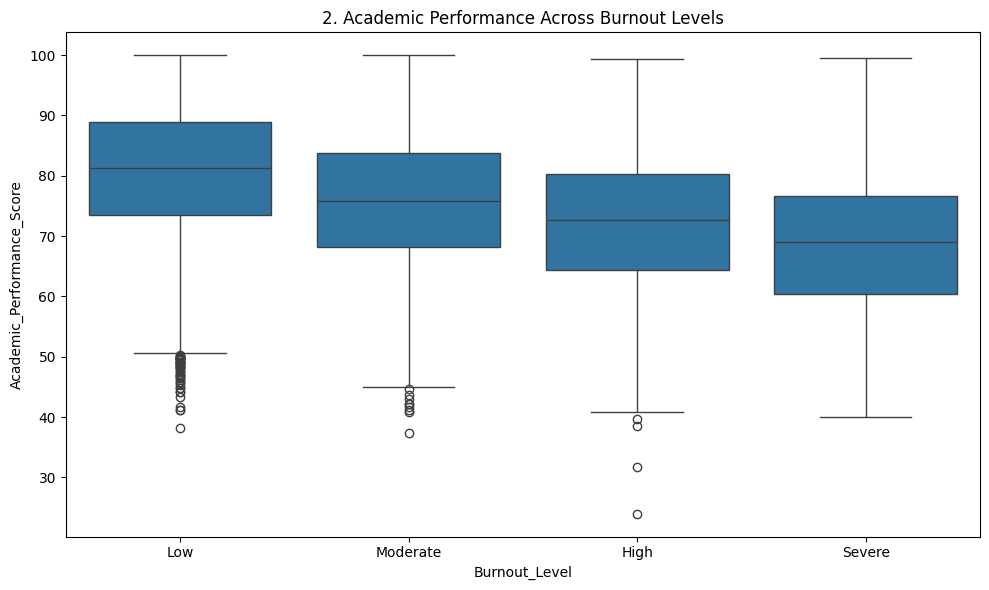

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Burnout_Level', y='Academic_Performance_Score')
plt.title(f'{plot_no}. Academic Performance Across Burnout Levels')
show_fig()
plot_no += 1

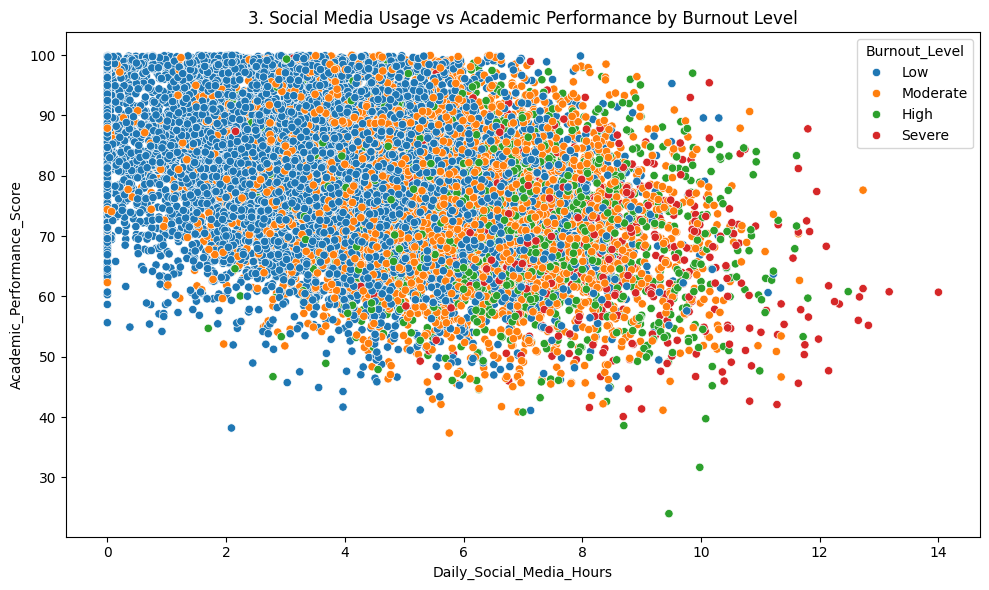

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Daily_Social_Media_Hours', y='Academic_Performance_Score', hue='Burnout_Level')
plt.title(f'{plot_no}. Social Media Usage vs Academic Performance by Burnout Level')
show_fig()
plot_no += 1

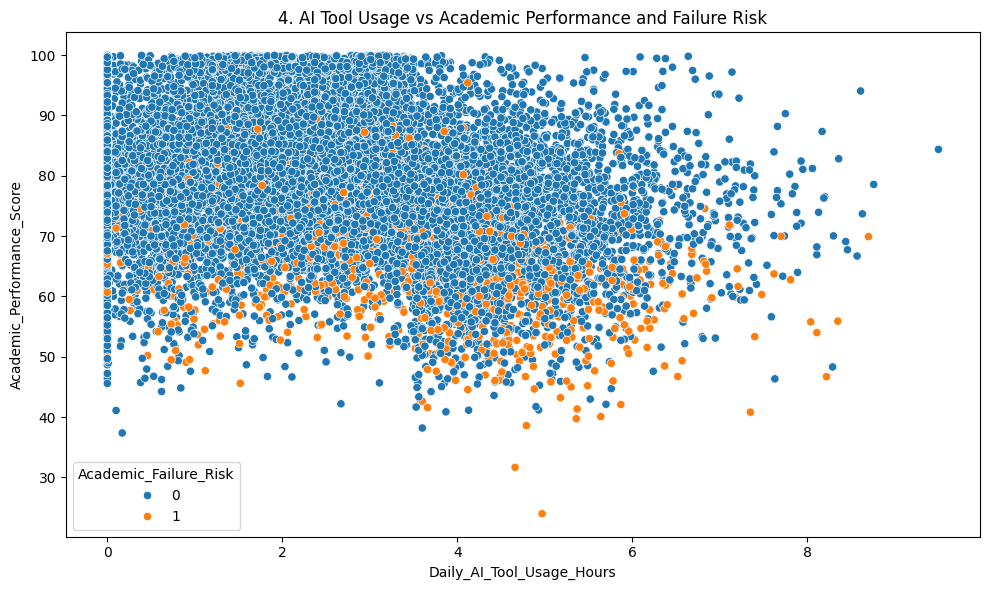

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Daily_AI_Tool_Usage_Hours', y='Academic_Performance_Score', hue='Academic_Failure_Risk')
plt.title(f'{plot_no}. AI Tool Usage vs Academic Performance and Failure Risk')
show_fig()
plot_no += 1

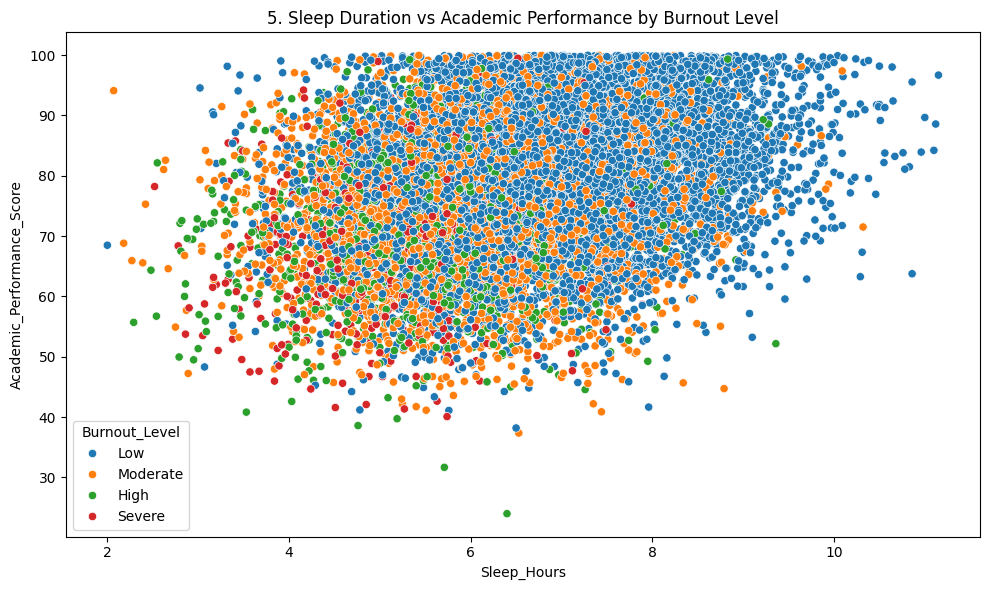

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sleep_Hours', y='Academic_Performance_Score', hue='Burnout_Level')
plt.title(f'{plot_no}. Sleep Duration vs Academic Performance by Burnout Level')
show_fig()
plot_no += 1

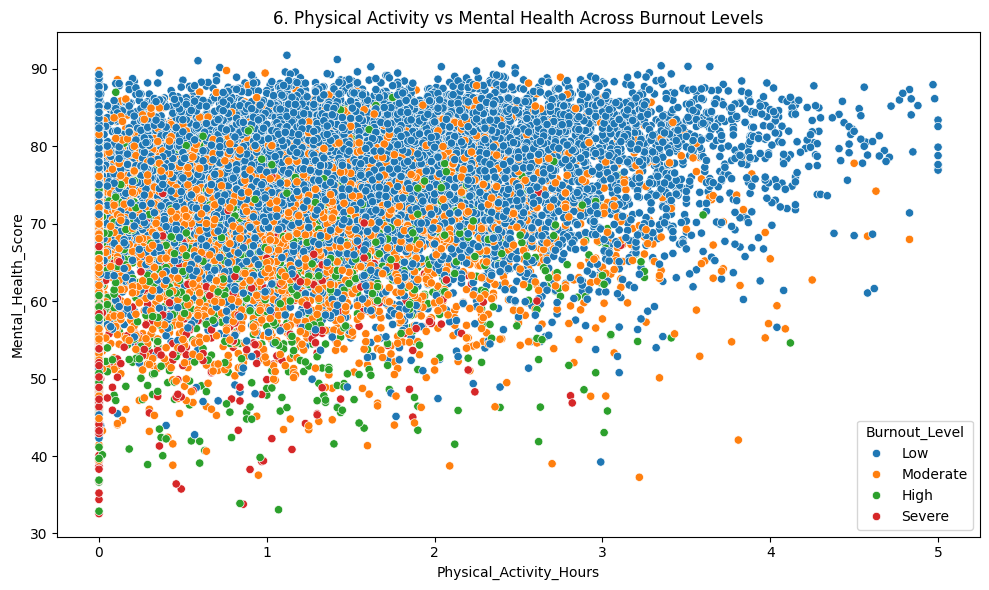

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Physical_Activity_Hours', y='Mental_Health_Score', hue='Burnout_Level')
plt.title(f'{plot_no}. Physical Activity vs Mental Health Across Burnout Levels')
show_fig()
plot_no += 1

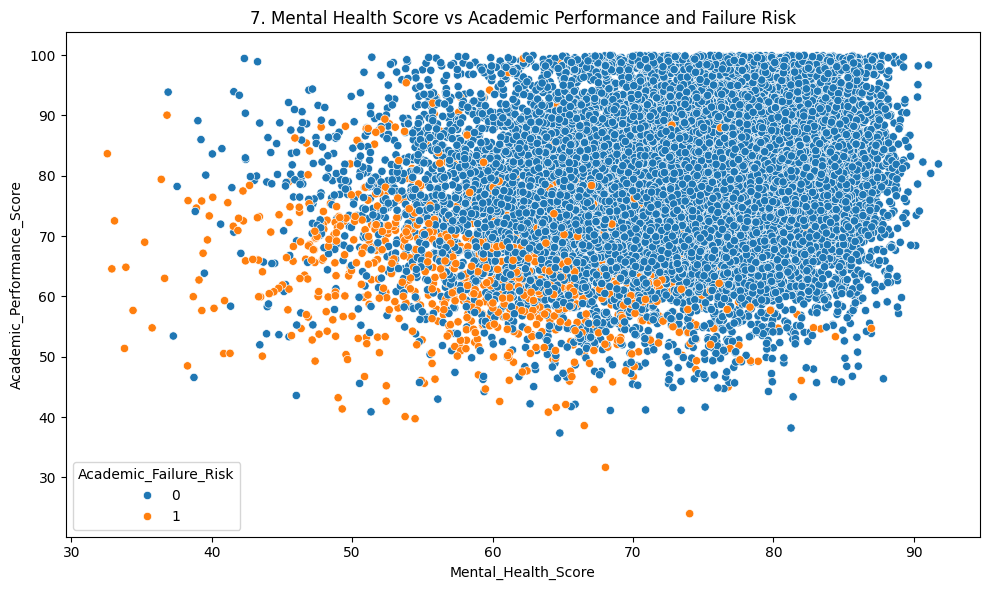

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Mental_Health_Score', y='Academic_Performance_Score', hue='Academic_Failure_Risk')
plt.title(f'{plot_no}. Mental Health Score vs Academic Performance and Failure Risk')
show_fig()
plot_no += 1

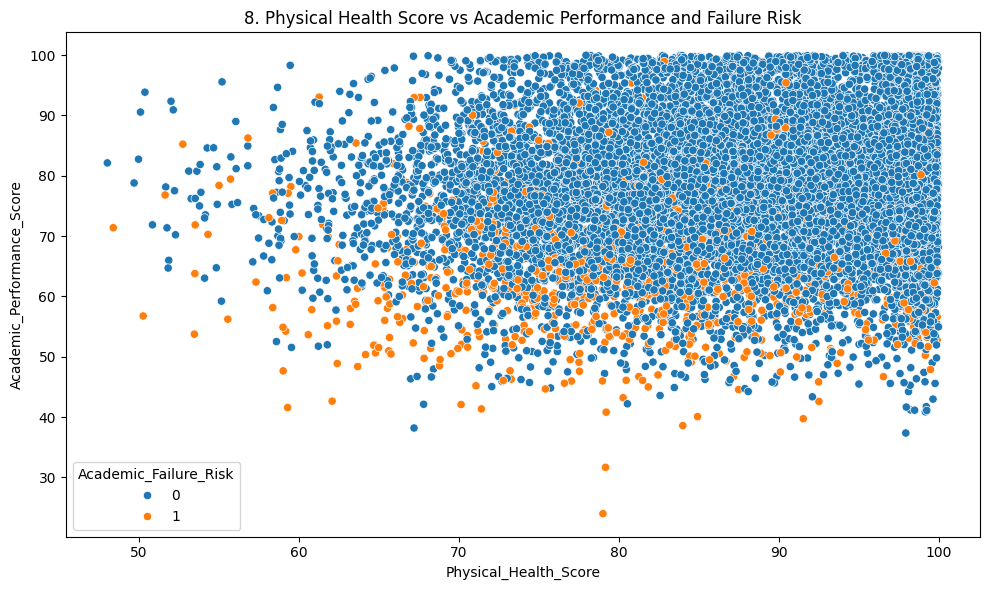

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Physical_Health_Score', y='Academic_Performance_Score', hue='Academic_Failure_Risk')
plt.title(f'{plot_no}. Physical Health Score vs Academic Performance and Failure Risk')
show_fig()
plot_no += 1

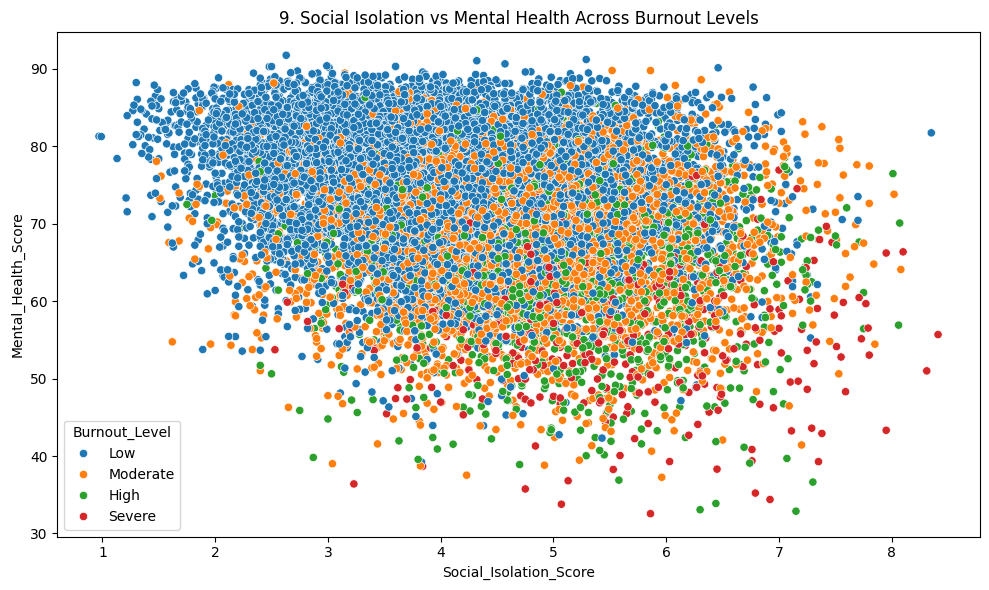

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Social_Isolation_Score', y='Mental_Health_Score', hue='Burnout_Level')
plt.title(f'{plot_no}. Social Isolation vs Mental Health Across Burnout Levels')
show_fig()
plot_no += 1

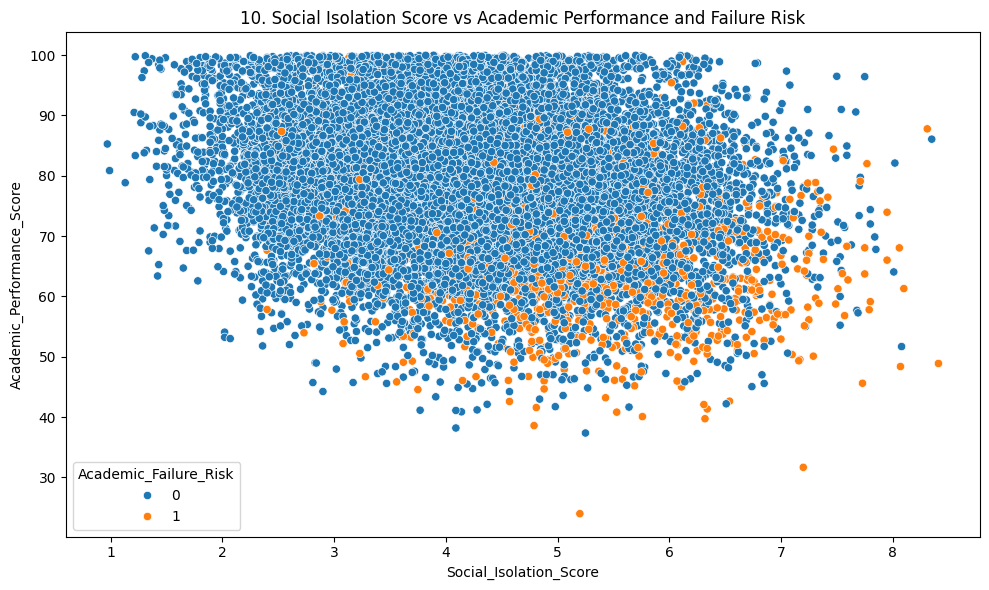

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Social_Isolation_Score', y='Academic_Performance_Score', hue='Academic_Failure_Risk')
plt.title(f'{plot_no}. Social Isolation Score vs Academic Performance and Failure Risk')
show_fig()
plot_no += 1

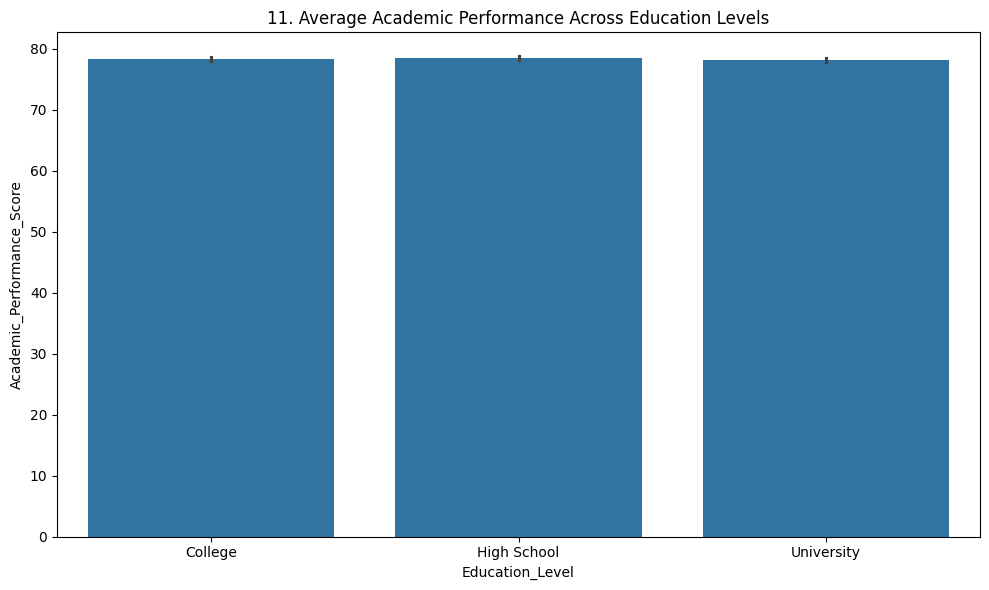

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Education_Level', y='Academic_Performance_Score', estimator='mean')
plt.title(f'{plot_no}. Average Academic Performance Across Education Levels')
show_fig()
plot_no += 1

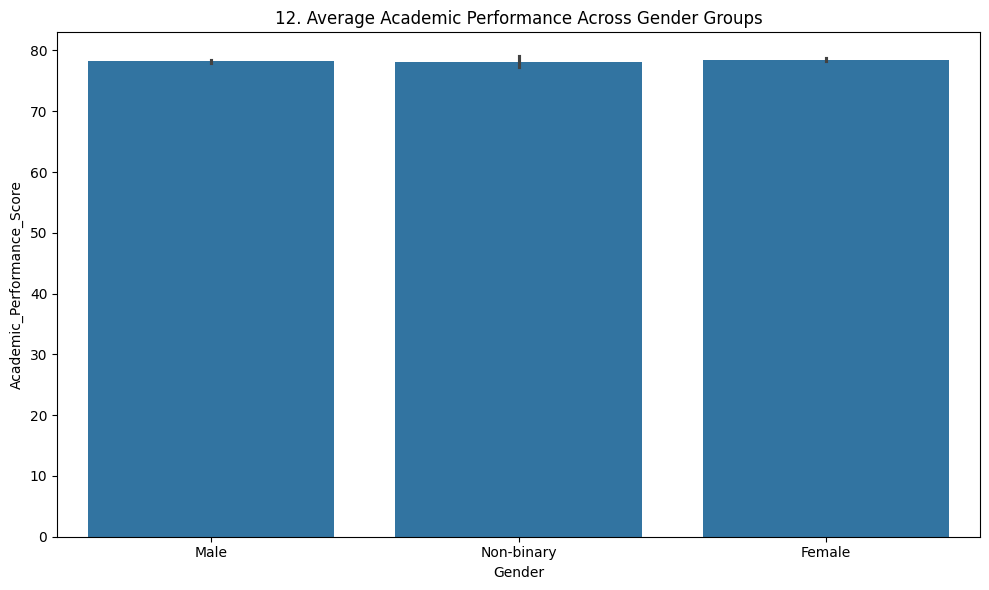

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Gender', y='Academic_Performance_Score', estimator='mean')
plt.title(f'{plot_no}. Average Academic Performance Across Gender Groups')
show_fig()
plot_no += 1

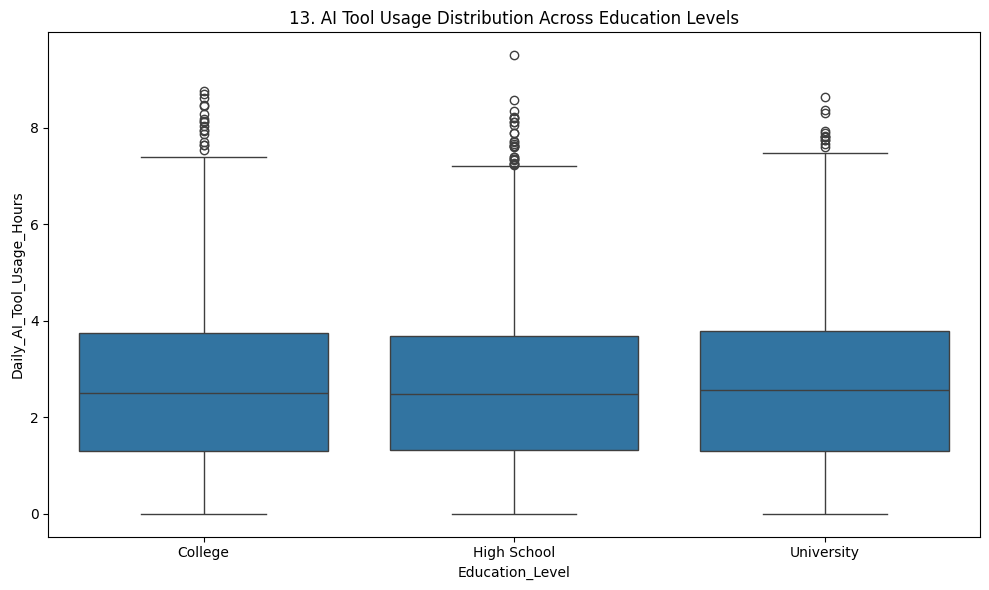

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Education_Level', y='Daily_AI_Tool_Usage_Hours')
plt.title(f'{plot_no}. AI Tool Usage Distribution Across Education Levels')
show_fig()
plot_no += 1

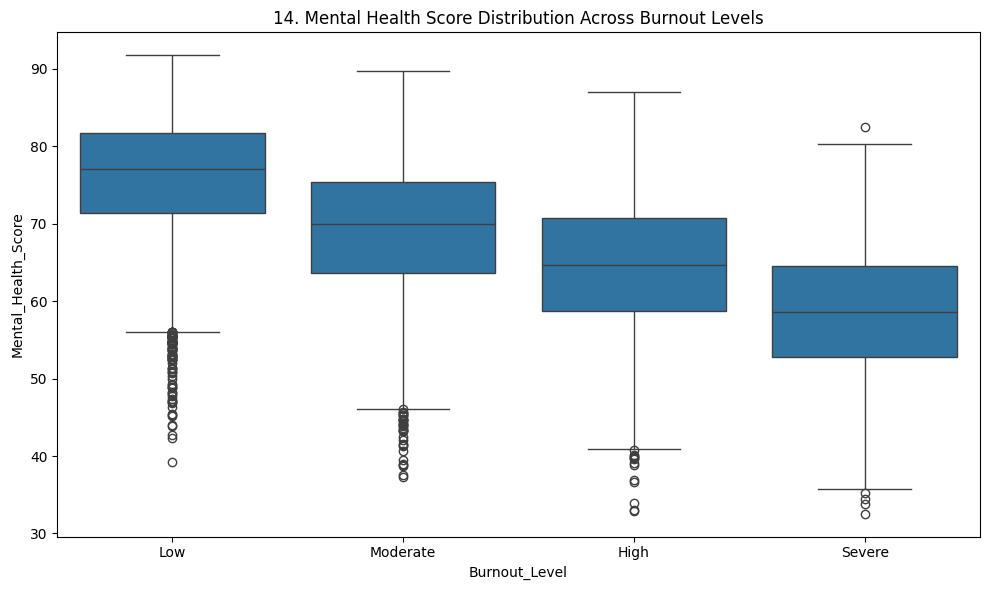

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Burnout_Level', y='Mental_Health_Score')
plt.title(f'{plot_no}. Mental Health Score Distribution Across Burnout Levels')
show_fig()
plot_no += 1

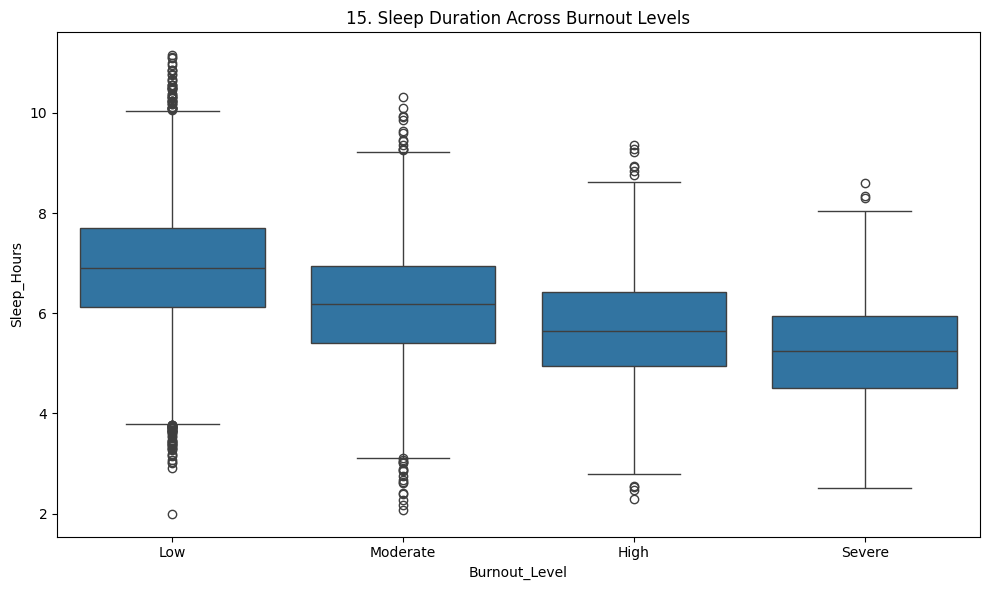

In [27]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Burnout_Level', y='Sleep_Hours')
plt.title(f'{plot_no}. Sleep Duration Across Burnout Levels')
show_fig()
plot_no += 1

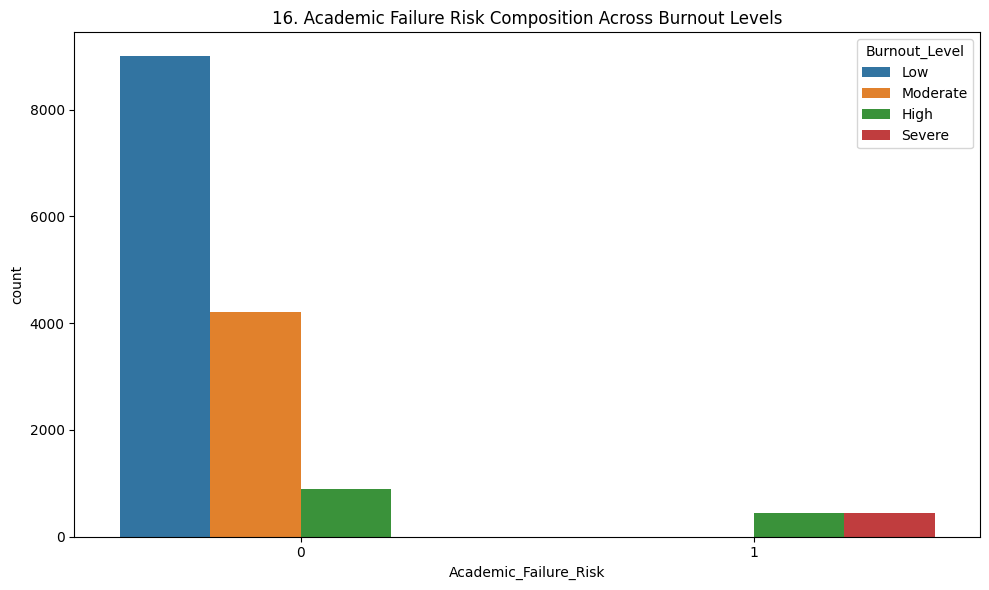

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Academic_Failure_Risk', hue='Burnout_Level')
plt.title(f'{plot_no}. Academic Failure Risk Composition Across Burnout Levels')
show_fig()
plot_no += 1

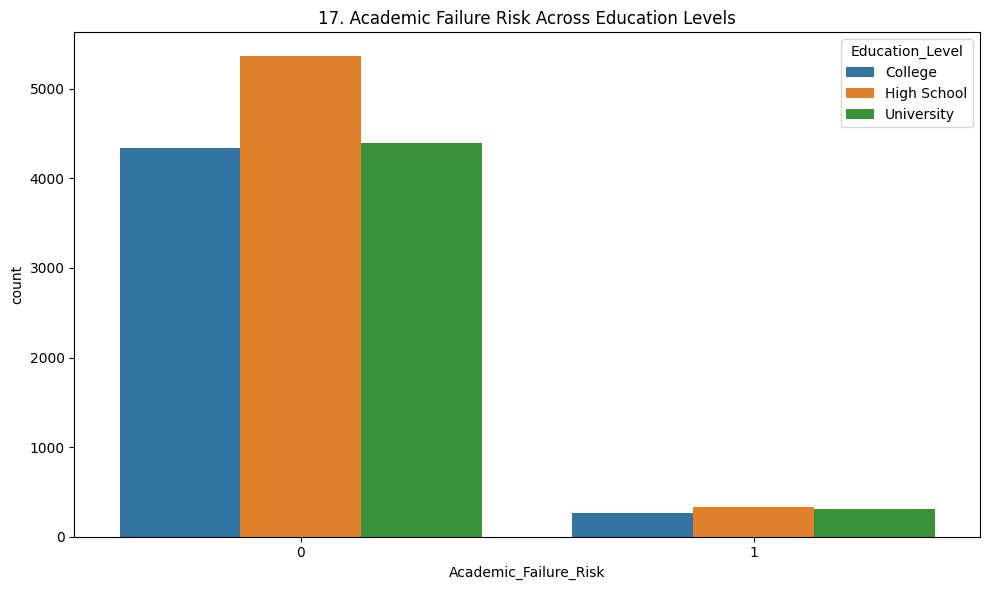

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Academic_Failure_Risk', hue='Education_Level')
plt.title(f'{plot_no}. Academic Failure Risk Across Education Levels')
show_fig()
plot_no += 1

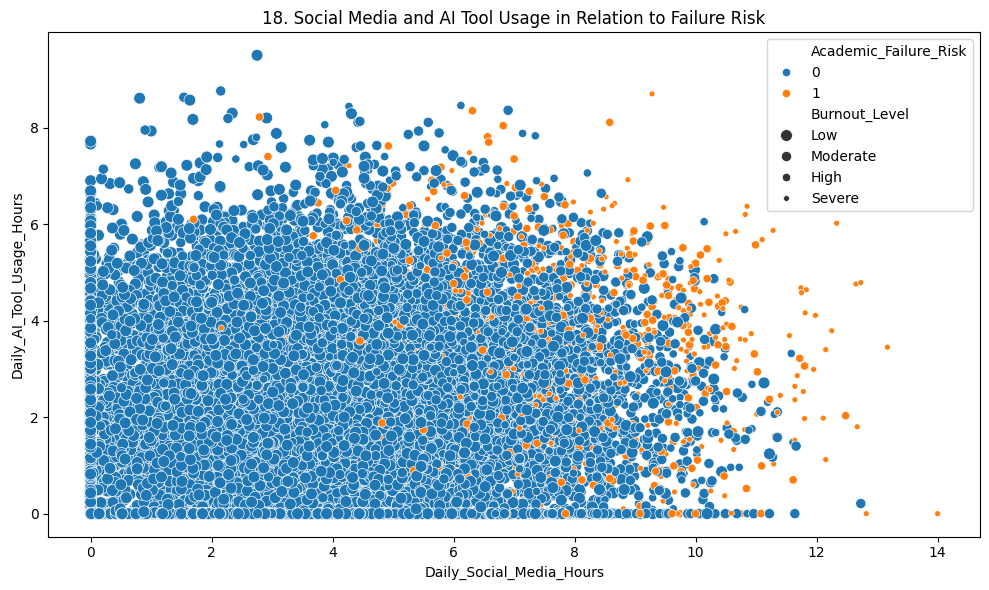

In [30]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Daily_Social_Media_Hours', y='Daily_AI_Tool_Usage_Hours', size='Burnout_Level', hue='Academic_Failure_Risk')
plt.title(f'{plot_no}. Social Media and AI Tool Usage in Relation to Failure Risk')
show_fig()
plot_no += 1

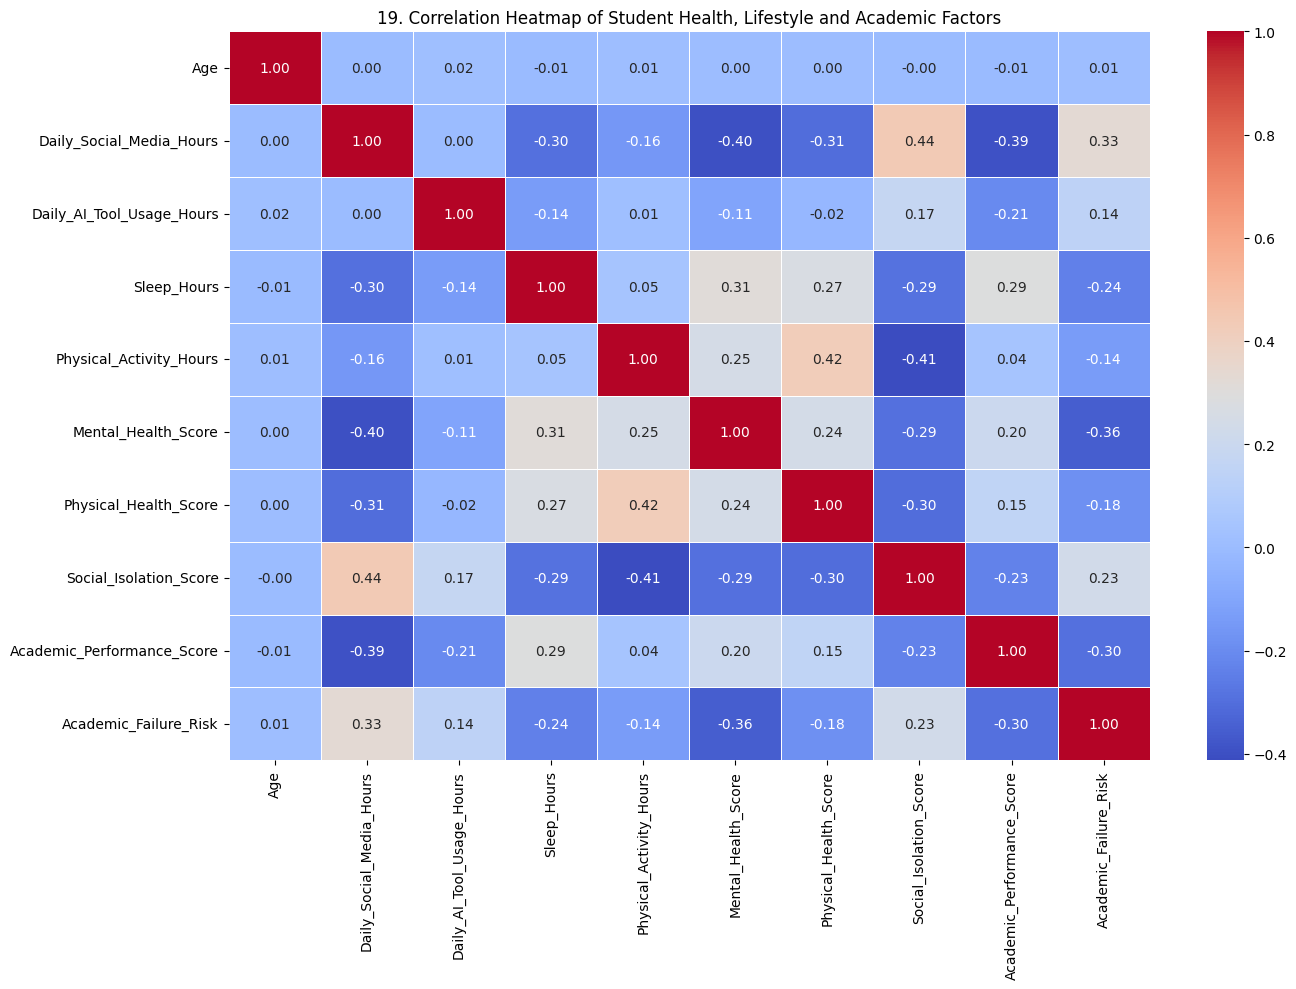

In [31]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Student Health, Lifestyle and Academic Factors')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [32]:
X = df[['Age', 'Daily_Social_Media_Hours', 'Daily_AI_Tool_Usage_Hours',
        'Sleep_Hours', 'Physical_Activity_Hours', 'Mental_Health_Score',
        'Physical_Health_Score', 'Social_Isolation_Score',
        'Academic_Performance_Score']].copy()

y = df['Academic_Failure_Risk'].copy()

## Remove rows with missing values

In [33]:
data = pd.concat([X, y], axis=1).dropna()

In [34]:
X = data.drop(columns=['Academic_Failure_Risk'])
y = data['Academic_Failure_Risk']

## Encode the target variable

In [35]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

## Split the dataset

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scale the features

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train Logistic Regression model

In [38]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Make predictions

In [39]:
y_pred = model.predict(X_test)

## Calculate accuracy

In [40]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 95.20%


## Display confusion matrix

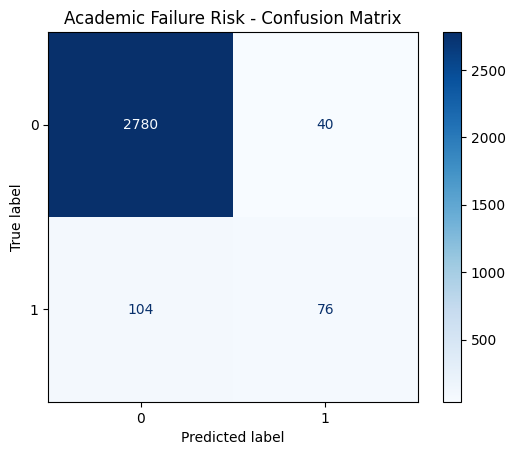

In [41]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap='Blues')
plt.title('Academic Failure Risk - Confusion Matrix')
plt.show()